Remote Sudoku
--
    
<img src='https://www.janestreet.com/puzzles/20190401_remote_sudoku.png' width=400 align='center'/>

Fill each cell — even the ones with grey numbers — with a digit between 1 and 9 so that each row, column, and outlined 3-by-3 squares contains each digit once.

A grey number _N_ indicates that there is an _N_ exactly _N_ squares away (horizontally or vertically).

**The answer to this month’s puzzle is the sum of the squares of the numbers written over the gray numbers in the completed grid.**

(For example, if a 7 is written over one of the grey numbers, that would contribute 49 towards the sum.)


In [121]:
import time
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from z3 import *

In [125]:
def _distanceAdder(number: int, y: int, x: int) -> list[tuple]:
    l = []
    if y - number >= 0:
        l.append((y - number, x))
    if y + number < 9:
        l.append((y + number, x))
    if x - number >= 0:
        l.append((y, x - number))
    if x + number < 9:
        l.append((y, x + number))

    return l

hints = [
    [2,0,0,0,7,1,8,3,6],
    [0,0,0,0,0,0,0,2,0],
    [0,0,5,0,0,5,4,0,2],
    [0,0,0,1,0,0,5,0,1],
    [8,3,3,0,1,0,2,4,4],
    [3,0,4,0,0,3,0,0,0],
    [6,0,2,3,0,0,5,0,0],
    [0,4,0,0,0,0,0,0,0],
    [7,2,7,3,1,0,0,0,3]
]

hints = np.array(hints)

In [135]:
s = Tactic("qffd").solver()

grid = np.array([[Int(f"X_{[j,i]}") for i in range(9)] for j in range(9)])

#All digits are between 1-9
for j, row in enumerate(grid):
    for i, cell in enumerate(row):
        s += cell > 0
        s += cell < 10

#All digits in rows and cols are unique
for i, row in enumerate(grid):
    s += Distinct([x for _, x in enumerate(row)])
for i, col in enumerate(grid.T):
    s += Distinct([x for _, x in enumerate(col)])

#All digits in one block are unique
s += [Distinct([grid[3*i0 + i][3*j0 + j] for i in range(3) for j in range(3)])
             for i0 in range(3) for j0 in range(3)]

#Apply hints:
for j, row in enumerate(grid):
    for i, cell in enumerate(row):
        if hints[j][i] != 0:
            l = _distanceAdder(hints[j][i], j, i)
            s += Or([grid[y][x] == hints[j][i] for y, x in l])


start = time.perf_counter()
if s.check() == sat:
    m = s.model()
    sol = np.array([[m[cell].as_long() for cell in row] for row in grid])
    print(sol)

end = time.perf_counter()
print(f"Time elapsed is {(end - start):.2f} seconds")
ans = [sum([int(sol[y][x]**2) for x,col in enumerate(row) if col > 0]) for y,row in enumerate(hints)]
print(f"Solution is {sum(ans)}")

[[6 9 2 5 3 7 1 8 4]
 [1 3 7 8 4 2 5 6 9]
 [5 8 4 1 9 6 2 3 7]
 [4 5 3 7 8 9 6 1 2]
 [9 1 6 4 2 3 7 5 8]
 [7 2 8 6 1 5 4 9 3]
 [2 7 1 9 5 8 3 4 6]
 [8 6 5 3 7 4 9 2 1]
 [3 4 9 2 6 1 8 7 5]]
Time elapsed is 0.04 seconds
Solution is 1105


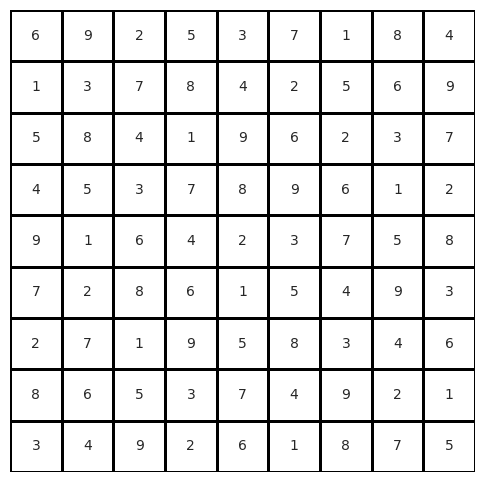

In [141]:
def gridshow(grid: np.array) -> None:
    plt.figure(figsize=(6, 6))
    heatmap = sns.heatmap(grid, annot=True, cmap=ListedColormap(['white']), cbar=False, xticklabels = False, yticklabels = False, linewidths=1, linecolor="black")
    plt.show()

gridshow(sol)